# Dataset Characterization

the idea of this notebook is to characterize the dataset only, regarding only structures dft data, maybe composition , ternary plot, and this kind of things.

input: `CuratedBriefSummary.pkl` 

output: plots

In [1]:
from Tools.DatasetTools.Commoms import *
dataset = 'Cr-Co-W'#'Fe-Mo/'
sys.path.insert(0, '/home/storage/fortimtb/CuadernoTrabajo/bopfoxfeaturizer/')
from BopFoxFeaturizer.Featurizer  import Featurizer
plt.style.use('default')
plt.rc('figure', figsize=(15,10))
plt.rc('font', size=22)
plt.rc('text', usetex=True)


In [2]:
BSfile = os.path.join(dataset,'CuratedParsedBriefSummary.pkl' )
BS = pd.read_pickle(BSfile)
Features = Featurizer(BS)

# Compositions 

# Population of phases

(array([ 53.,  16., 481., 472., 475., 162.,  17.,  30.,  17.,  39.]),
 array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.]),
 <BarContainer object of 10 artists>)

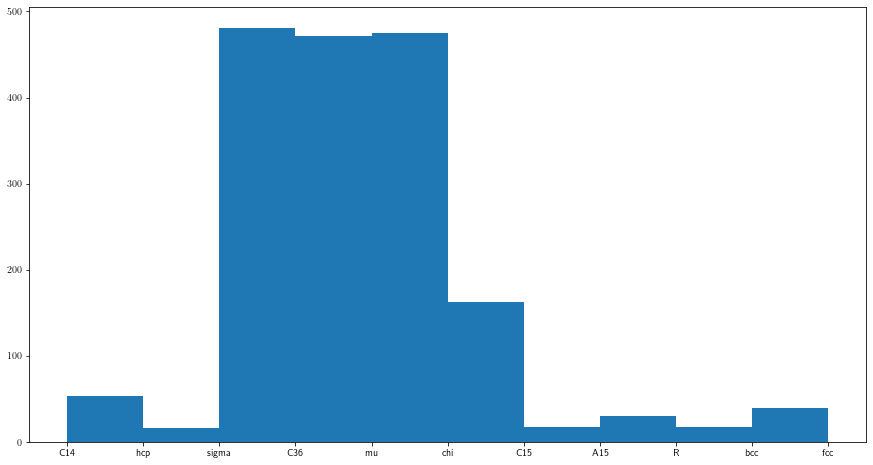

In [3]:
fig, ax = plt.subplots(figsize=(15,8))
# sns.histplot(x = BS['Phase'], ax=ax)
ax.hist(BS['Phase'])

<AxesSubplot:ylabel='Count'>

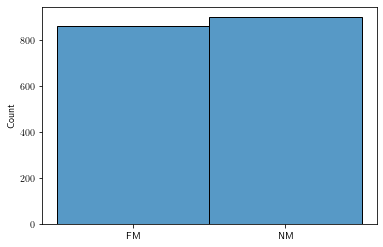

In [4]:
sns.histplot(x = Features.Mag)

In [5]:
isfm = Features.Mag.str.contains('FM')

In [6]:
fmsamples = BS.index[isfm]

In [7]:
fmsamplesasnm = fmsamples.str.replace('.FM$','.NM')

In [8]:
nmsamples = BS.index[~isfm]

## fm samples without nm counterpart:

In [9]:
nmsamples.difference(fmsamplesasnm)

Index(['Co_pv14W_sv10.C36-AABAB.NM', 'Co_pv14W_sv10.C36-BAAAB.NM',
       'Co_pv15W_sv38.R-AAAABBBBBBB.NM', 'Co_pv18W_sv6.C36-AAAAB.NM',
       'Co_pv1W_sv3.D03-AB3.NM', 'Co_pv1W_sv52.R-ABBBBBBBBBB.NM',
       'Co_pv21W_sv32.R-AAAAABBBBBB.NM', 'Co_pv27W_sv26.R-AAAAAABBBBB.NM',
       'Co_pv2W_sv11.mu-BBBAB.NM', 'Co_pv2W_sv11.mu-BBBBA.NM',
       'Co_pv2W_sv2.B32-AB.NM', 'Co_pv2W_sv6.D0_19-AB3.NM',
       'Co_pv33W_sv20.R-AAAAAAABBBB.NM', 'Co_pv3W_sv1.D03-A3B.NM',
       'Co_pv3W_sv10.mu-ABBBA.NM', 'Co_pv3W_sv50.R-AABBBBBBBBB.NM',
       'Co_pv45W_sv8.R-AAAAAAAAABB.NM', 'Co_pv47W_sv6.R-AAAAAAAAAAB.NM',
       'Co_pv4W_sv20.C36-ABBBB.NM', 'Co_pv4W_sv20.C36-BBABB.NM',
       'Co_pv4W_sv26.sigma-BABBB.NM', 'Co_pv6.C15.NM',
       'Co_pv6W_sv18.C36-BBBBA.NM', 'Co_pv6W_sv2.D0_19-A3B.NM',
       'Co_pv6W_sv24.sigma-AABBB.NM', 'Co_pv8.A15.NM',
       'Co_pv8W_sv16.C36-AABBB.NM', 'Co_pv8W_sv16.C36-ABABB.NM',
       'Co_pv9W_sv44.R-AAABBBBBBBB.NM', 'Cr_pv10Co_pv14.C36-ABBBA.NM',
       'Cr_pv10C

## nm samples as without fm counterpart:

In [10]:
fmsamplesasnm.difference(nmsamples)

Index(['Co_pv30.sigma_Co_pv.NM', 'Cr_pv1Co_pv1.B2-AB.NM',
       'Cr_pv1Co_pv1.L10-NiAl-AB.NM', 'Cr_pv1Co_pv1.hcp-AB.NM',
       'Cr_pv1Co_pv3.L12-AB3.NM', 'Cr_pv2Co_pv8W_sv3.mu-CBBCA.NM',
       'Cr_pv30.sigma_Cr_pv.NM', 'Cr_pv3Co_pv1.L12-A3B.NM',
       'Cr_pv5Co_pv1W_sv2.A15-AAAAABCC.NM',
       'Cr_pv5Co_pv1W_sv2.A15-AAAABACC.NM',
       'Cr_pv5Co_pv1W_sv2.A15-AAABAACC.NM',
       'Cr_pv5Co_pv1W_sv2.A15-AABAAACC.NM',
       'Cr_pv5Co_pv1W_sv2.A15-ABAAAACC.NM',
       'Cr_pv5Co_pv1W_sv2.A15-BAAAAACC.NM',
       'Cr_pv5Co_pv2W_sv1.A15-AAAAACBB.NM',
       'Cr_pv5Co_pv2W_sv1.A15-AAAACABB.NM',
       'Cr_pv5Co_pv2W_sv1.A15-AAACAABB.NM',
       'Cr_pv5Co_pv2W_sv1.A15-AACAAABB.NM',
       'Cr_pv5Co_pv2W_sv1.A15-ACAAAABB.NM',
       'Cr_pv5Co_pv2W_sv1.A15-CAAAAABB.NM',
       'Cr_pv6Co_pv1W_sv1.A15-AAAAAABC.NM', 'W_sv4.fcc-cubic.NM'],
      dtype='object', name='index')

#  Obvious outliers removal

In [11]:
BS = BS[(BS.B0 > 0 ) ]

# Distribution of Target Variables 

## total energy

In [12]:
targets = {'E0':r'$E_0$', 'B0':r'$B_0$', 'V0':r'$V_0$'}

some obvious outliers:

In [13]:
if dataset == 'Cr-Co-W':
    BS = BS[(BS['E0']>-500) & (BS['V0']<40)]

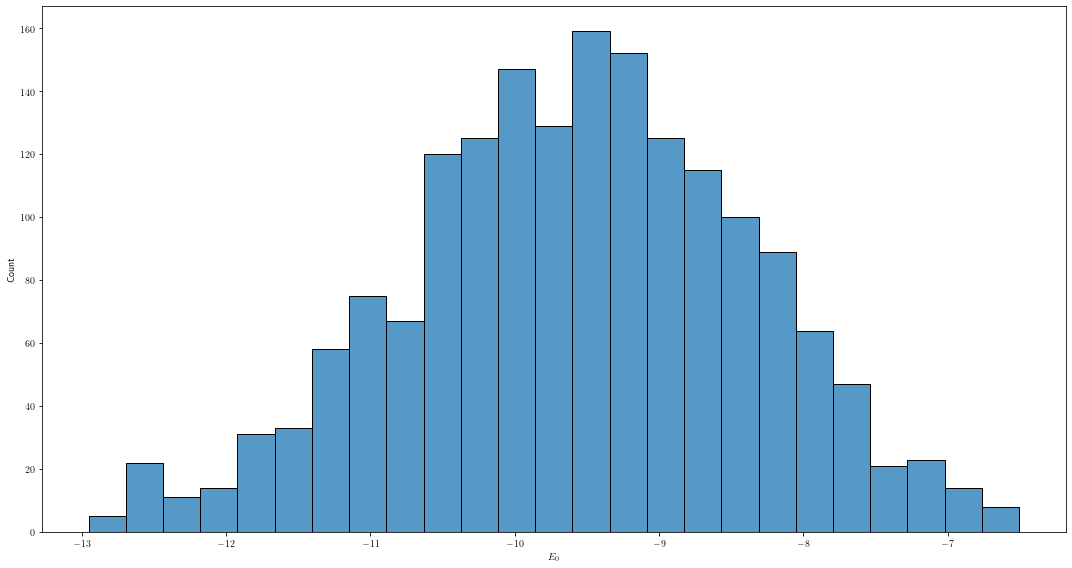

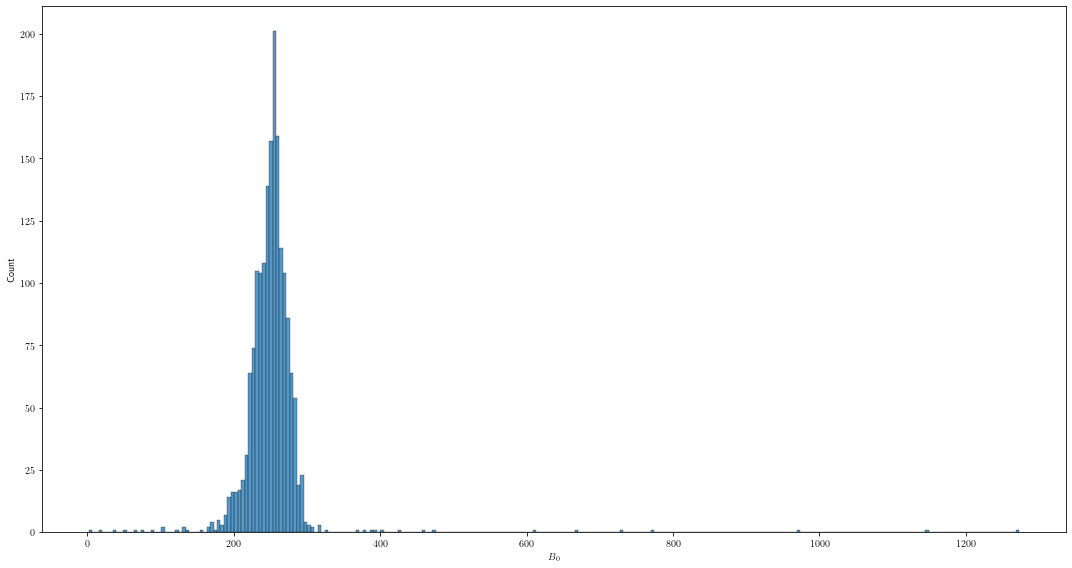

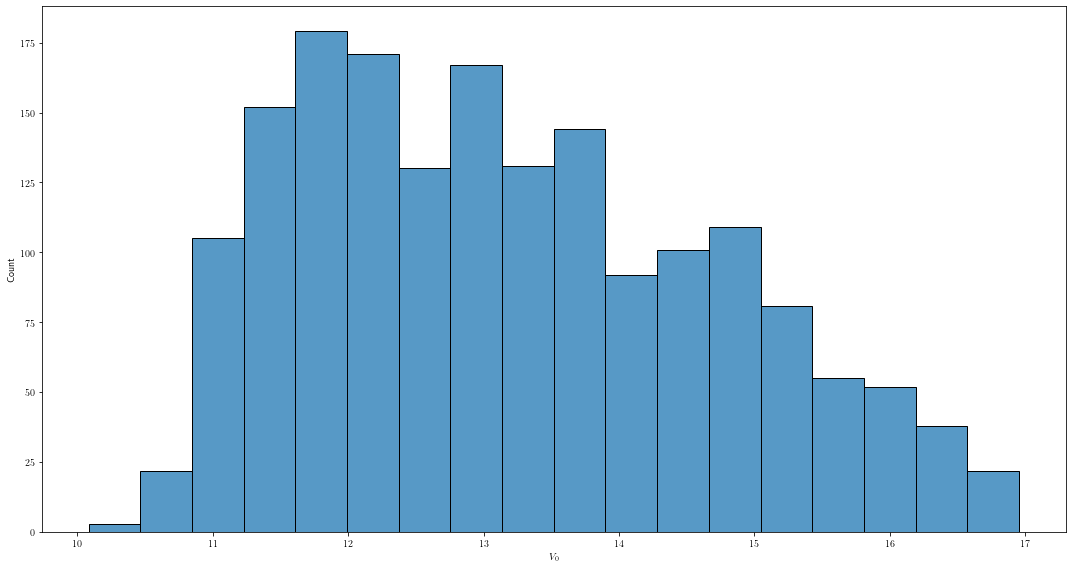

In [14]:
for target, label in targets.items():
    fig, ax = plt.subplots(figsize = (15,8 ))
    sns.histplot(x = BS[target], ax = ax)
    ax.set_xlabel(label)
    fig.tight_layout()

# General correlation

In [15]:
BS.sort_values(by='B0', inplace=True)

Text(11.109495, -7.81368, 'Cr_pv5Co_pv8.mu-ABAAB.FM')

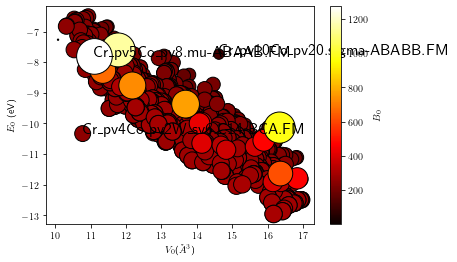

In [16]:
#fig, ax = plt.subplots()
plt.scatter(BS.V0, BS.E0, c=BS.B0, marker = 'o' , s = BS.B0, cmap='hot', edgecolor='k')
cbar = plt.colorbar()
plt.ylabel(targets['E0']+' (eV)')
plt.xlabel(targets['V0']+'($\AA^3$)')
cbar.set_label(targets['B0'])
outlier_right = BS[(BS['E0']>-8) & (BS['V0']>14)].index
outlier_left =BS[(BS['E0']<-10) & (BS['V0']<11)].index
plt.annotate(outlier_left[0],*BS.loc[outlier_left][['V0', 'E0']].values, fontsize=16 )
plt.annotate(outlier_right[0],*BS.loc[outlier_right][['V0', 'E0']].values,fontsize=16)
outlier_high_b0 = BS[BS['B0']>1200].index
plt.annotate(outlier_high_b0[0],*BS.loc[outlier_high_b0][['V0', 'E0']].values, fontsize=16)

from the plots below, we only would put in the paper the one with _V_0 in x, E_0 in y and B_0 in color coding_

# Very low B0 or very High B0
The bulk modulus of compounds should not be greater that the hardest pure element or lower that the softest pure element

In [17]:
minB0  = BS[( BS.nelem == 1 )].B0.idxmin()

In [18]:
maxB0 = BS[( BS.nelem == 1 )].B0.idxmax()

In [19]:
minB0, maxB0

('Co_pv24.C36.FM', 'W_sv1.bcc.NM')

In [20]:
BS.B0[[ minB0, maxB0 ]]

index
Co_pv24.C36.FM    185.990763
W_sv1.bcc.NM      304.129156
Name: B0, dtype: float64

In [21]:
minB0val, maxB0val = BS.B0[[ minB0, maxB0 ]].values

In [22]:
BS[(BS['B0'] < 0.95*minB0val) | (BS['B0']>1.05*maxB0val)].B0.sort_values()

index
Cr_pv4Co_pv25.chi-BABB.FM               1.777361
Cr_pv16Co_pv4W_sv4.C36-BACAA.FM        19.348360
Cr_pv8Co_pv12W_sv4.C36-AACBB.FM        36.753632
Cr_pv4Co_pv12W_sv13.chi-CABC.FM        49.612461
Cr_pv4Co_pv8W_sv1.mu-CBAAB.FM          67.987767
Cr_pv8Co_pv16.C36-BAABB.FM             76.587431
Cr_pv10Co_pv14.C36-ABBAB.FM            87.421066
Cr_pv14Co_pv6W_sv4.C36-AACBA.FM       104.539707
Cr_pv10Co_pv20.sigma-ABABB.FM         106.045764
Cr_pv14Co_pv4W_sv6.C36-ABACA.FM       120.679637
Cr_pv8Co_pv4W_sv12.C36-ABACC.FM       132.666439
Cr_pv14Co_pv10.C36-AABAB.FM           132.874213
Cr_pv3Co_pv10.mu-ABBAB.FM             136.585559
Cr_pv10Co_pv14.C36-BABBA.FM           155.630160
Co_pv14W_sv16.sigma-AABBA.FM          163.400685
Cr_pv4Co_pv14W_sv6.C36-ABBBC.FM       167.511402
Cr_pv8Co_pv10W_sv6.C36-BAACB.FM       168.089154
Cr_pv8Co_pv10W_sv6.C36-ABABC.FM       169.848261
Cr_pv4Co_pv20.C36-BABBB.FM            170.078969
Cr_pv8Co_pv6W_sv10.C36-AACBC.FM       171.780701
Cr_pv12Co_pv6W

## remove too high and too low B0

In [23]:
BS = BS[(BS['B0'] > minB0val*0.95) & (BS['B0'] < maxB0val*1.05)] #.B0.sort_values()

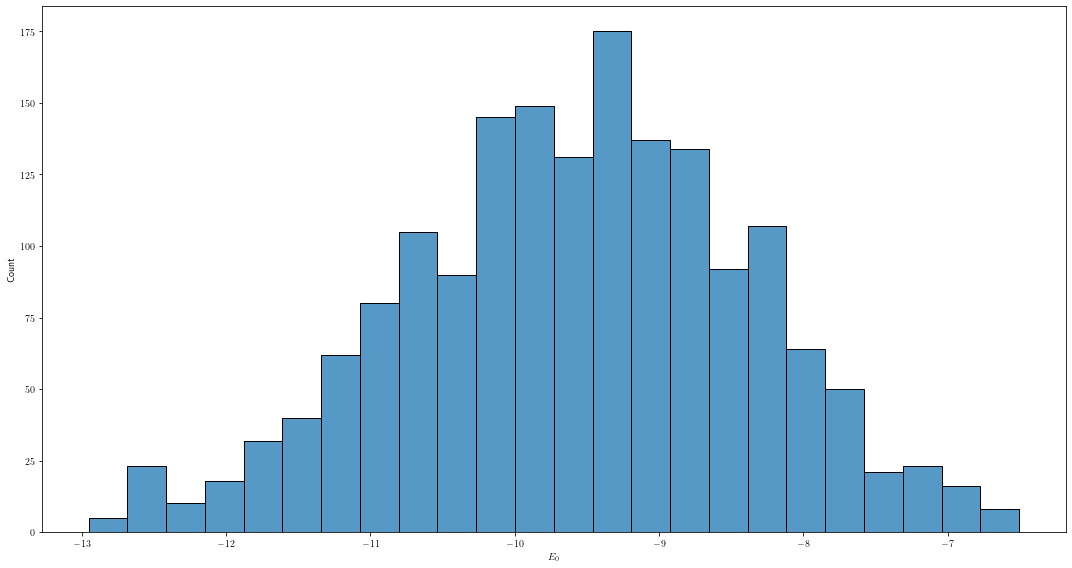

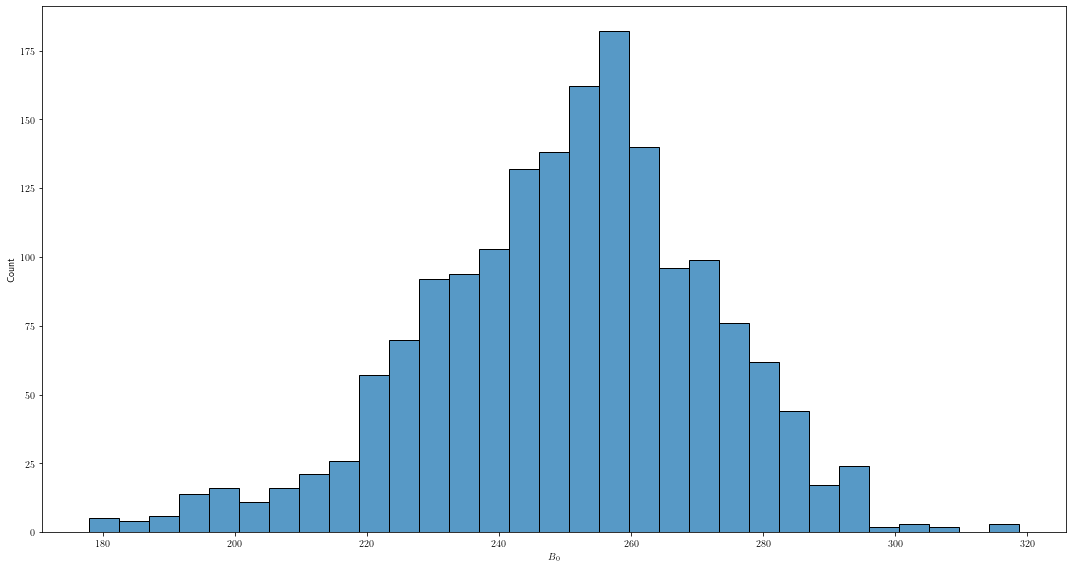

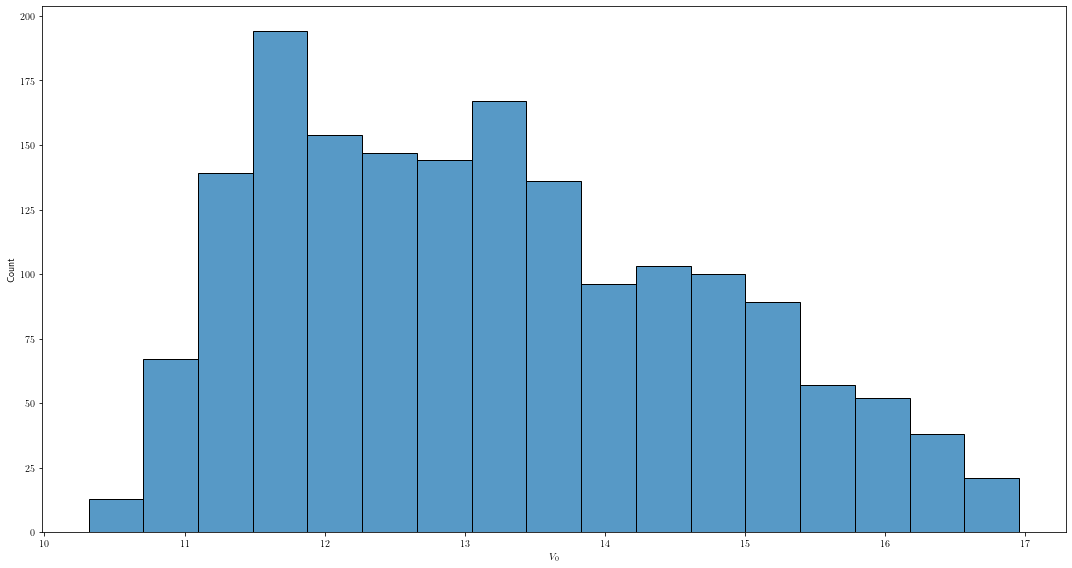

In [25]:
for target, label in targets.items():
    fig, ax = plt.subplots(figsize = (15,8 ))
    sns.histplot(x = BS[target], ax = ax)
    ax.set_xlabel(label)
    fig.tight_layout()

In [35]:
still_large = BS[BS.B0 > 310]

In [31]:
EVcurves = pd.read_json('Cr-Co-W/evcurves.json', orient='index', typ='series')
goodness = pd.read_json('Cr-Co-W/')

In [39]:
onexample=EVcurves[still_large.index][0]

In [52]:
onexample['xc=PBE-PAW.E=400.dk=0.020']['ev_fit_results']

{'E_murn': -11.936444999999999,
 'V_murn': 16.374534,
 'B_murn': 315.105053,
 'Bdev_murn': 8.238437}

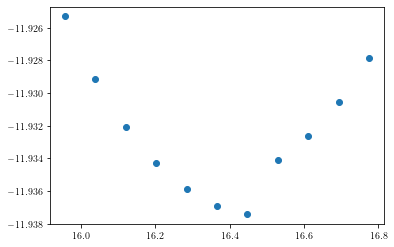

In [48]:
plt.plot(onexample['xc=PBE-PAW.E=400.dk=0.020']['evcurve']['V'], onexample['xc=PBE-PAW.E=400.dk=0.020']['evcurve']['E'], 'o')
plt.legend(onexample['xc=PBE-PAW.E=400.dk=0.020'])

In [54]:
BS.B0[still_large.index]

index
Cr_pv2W_sv11.mu-BBABB.FM            315.105053
Cr_pv20Co_pv4.C36-BAAAA.FM          318.529958
Cr_pv4Co_pv10W_sv10.C36-CABBC.FM    318.765831
Name: B0, dtype: float64

# Pair Plots

In [ ]:
ToPlot = BS[list(targets.keys())] #+['Phase']]
ToPlot.columns = list(targets.values()) #+['Phase']

In [ ]:
axis_grid = sns.pairplot(ToPlot, diag_kind = 'kde', kind='reg', height=8)
#, hue='Phase', x_vars=list(targets.values()), y_vars=list(targets.values()), )

# convex hulls ?

In [ ]:
import pandas as pd
from scipy.spatial import ConvexHull

In [ ]:
PhaseBS = {}
verts = {}

for phase in BS.Phase.unique():
    PhaseBS[phase] = BS[BS.Phase == phase]

In [ ]:
for phase, bs in PhaseBS.items():
    if bs.shape[0] <= 1:
        continue  # cant make CH with less than 1 sample
    chull = ConvexHull(bs.filter(regex='EF|Cr')[bs['nelem']==2])
    verts[phase] = chull.vertices

In [ ]:
irrelevant = ['sigma', 'chi', 'hcp','A15','C15' ,'fcc']

In [ ]:
verts

In [ ]:
PhaseBS['C36']['Cr_pv'].iloc[verts['C36']]

In [ ]:
PhaseBS['C36']['EF'][verts['C36']]

In [ ]:
fig = plt.figure()
ax = fig.add_axes([0.2,0.2,0.6,0.8])
for phase, vertices in verts.items():
    print(phase)
    if phase not in irrelevant:
    #    plt.plot(bs['Fe_pv'], bs['EF'], 'o')
        x = PhaseBS[phase].filter(regex='Cr').iloc[vertices].values.ravel()
        y = PhaseBS[phase]['EF'][vertices].values
        sorter = x.argsort()
        ax.plot(x[sorter], y[sorter], label=phase)
#ax.set_ylim([-0.05, 0.1])
ax2 = fig.add_axes([0.8, 0.2, 0.2, 0.8], sharey=ax)
ax2.hist(BS['EF'], bins=100, orientation='horizontal')
ax2.set_xlabel('counts')
ax2.yaxis.set_visible(False)
ax.set_xlabel('$x_{Cr}$')
ax.set_ylabel('$\Delta E_f$ (eV/atom)')
ax.legend()

In [ ]:
BS.to_pickle(os.path.join(dataset, f'FurtherCuratedParsedBriefSummary.pkl'))

# Compositions

In [ ]:
import plotly.express as pe

In [ ]:
BS